# Weight perturbation

## Theory

### Gradient descent optimization

Most deep learning algorithms involve optimization of some sort. Optimization
refers to the task of either minimizing or maximizing some function $f(x)$ by altering
$x$. We usually phrase most optimization problems in terms of minimizing $f(x)$. Maximization may be accomplished via a minimization algorithm by minimizing $-f(x)$. The function we want to minimize or maximize is called the objective function or criterion. When we are minimizing it, we may also call it the cost
function, loss function, or error function [3, p. 82].

We can decrease $f$ by moving in the direction of the negative gradient.
This is known as the method of steepest descent or gradient descent. A new point is then given by:
$$
x' = x - \eta \nabla_x f(x)
$$
where $\eta$ is the learning rate (step size) [3, p. 85,86].

### Weight perturbation
Consider a network getting input over a trial duration $T$ and generating output. Time is split into discrete steps, indexed by $t = 1, \dots , T$. At the end of a trial, it receives a scalar
error feedback $E$ about its performance.
To quantitatively introduce the learning rules, we consider a neuron $i$, which may be part of a larger network.
It generates in the $t$-th time bin an output firing rate $z_{it}$,
in response to the firing rates $r_{jt}$ of its $N$ presynaptic
neurons 
$$
z_{it} = g \left(\sum_{j=1}^N w_{ij} \cdot r_{jt} \right) 
$$
Here $g$ is the activation function (example sigmoid). 

Weight perturbation now happens when we add a (for example Gaussian distributed with mean 0 and standard deviation $\sigma$) noise $\epsilon$ to the weights at the beginning of each trial:
$$
z_{it}' = g \left(\sum_{j=1}^N \left[w_{ij} + \epsilon_{ij} \right]\cdot r_{jt} \right) 
$$
where the first two moments of the noise are 
$$
\braket{\epsilon_{ij}} = 0, \qquad \braket{\epsilon_{ij} \epsilon_{kl}} = \delta_{kl} \delta_{ij} \sigma^2
$$
In the following we introduce the learning rate $\eta$, the error of the perturbed trial $E' = E(w + \epsilon)$ and the error of the unperturbed trial $E(w)$. The errors will here be calculated via the squared differences of predicted and true output. The update rule we will use is given by [1, page 2]:
$$
\Delta w_{ij} = -\frac{\eta}{\sigma^2} (E'-E)\cdot \epsilon_{ij}
$$
and is in the average equal to gradient descent optimization. Using the Taylor expansion
$$
E' = E + \sum_{k,l} \left. \frac{\partial E(w_{kl} + \epsilon_{kl})}{\partial (w_{kl} + \epsilon_{kl})} \right|_{\epsilon_{kl} = 0} \cdot \epsilon_{kl} + \mathcal{O}(\epsilon_{kl}^2) \approx E + \sum_{k,l} \frac{\partial E}{\partial w_{kl}} \cdot \epsilon_{kl}
$$
this expression can be rewritten to:
\begin{align*}
 \Delta w_{ij} &= -\frac{\eta}{\sigma^2} (E'-E)\cdot \epsilon_{ij} \\
 & \approx -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \epsilon_{kl} \right) \cdot \epsilon_{ij}
\end{align*}
If one now takes the average this yields
\begin{align*}
 \braket{\Delta w_{ij}} &\approx -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \braket{\epsilon_{kl} \cdot \epsilon_{ij}} \right)\\
 & = -\frac{\eta}{\sigma^2} \left( \sum_{k,l} \frac{\partial E}{ \partial w_{kl}} \, \delta_{ki} \delta_{lj} \sigma^2 \right) \\
 & = - \eta \frac{\partial E}{ \partial w_{ij}} 
\end{align*}

## Simple spiking networks
We will now construct a simple, single layer neural network. We will use three input neurons and one output neuron. The Inputs $I_1, I_2, I_2$ are $n$-dimensional, binary vectors. The weights $w_1,w_2,w_3$ will be trained such that a desired output can be reached.  The used update rule is the WP rule from above. Additionally, we consider 3 different activation functions: sigmoid, linear and step-function. Additionally, the weight and error convergence will be plotted and described.

### Import packages

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

# Plot specifications
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['legend.fontsize']  = 14
matplotlib.rcParams['xtick.labelsize']  = 14
matplotlib.rcParams['ytick.labelsize']  = 14
matplotlib.rcParams['axes.titlesize']  = 17
matplotlib.rcParams['axes.labelsize']  = 17



# Plot two given lists x and y against each other
def visualize(x, y, data_label, xlabel, ylabel, color, linestyle='.', transparency = 1):
    # Plot the data
    plt.plot(x, y, linestyle, color=color, alpha=transparency)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(alpha=0.3)
    #plt.legend()

### Create a teacher function

In order to generate some reachable output, we create a teacher function, that takes the same inputs as the neuron and has some specific weight values $w_1^*, w_2^*, w_3^*$. These are then used to calculate the target output, yielding a reachable output for our network. 

### Create complete network

Now we set up the complete network, where a the teacher can be used or not. The weights are computed via the WP algorithm and the weight values as well as the error for each training epoch will be plotted. From the theory we expect the error to converge exponentially towards some final error. Also for WP we do not expect the error to become greater at any point.

In [2]:
import random

class linear_perceptron:
    
    def __init__(self,
        eta,                 # Learning rate
        sigma,               # std of the gaussian noise
        T,                   # Vector length
        num_iterations,      # Number of iterations for weight update
        activation_type,     # Set activation function
        use_teacher,         # Use a teacher function to generate target
        plot_weight,         # Wether the evolution of weights should be plotted
        spike_number,        # Number of total spikes
        input_neuron_number, # Number of neurons in input layer
        plot_errors = True,  # Wether to plot the error evolution
        sigma_0 = 1,         # Value of start weight std
        ):
        
        self.sigma = sigma / np.sqrt(input_neuron_number*spike_number/T)
        self.T = T
        self.num_iterations = num_iterations
        self.activation_type = activation_type
        self.use_teacher = use_teacher
        self.plot_weight = plot_weight
        self.input_neuron_number =  input_neuron_number 
        self.spike_number = spike_number
        self.input_strength = self.spike_number/self.T
        self.eta = eta
        self.plot_errors = plot_errors
        self.sigma_0 = sigma_0
        # Collect errors for plot
        self.err = []
        self.err_WP = []
        # Collect first 3 weight values for plot
        self.w1 = []
        self.w2 = []
        self.w3 = []
       
   
    #----------------------------------------------------#
    #             Generate incoming spike train
    #----------------------------------------------------#  
    def spike_train(self):
        # Setting a seed, which guarantees reproducibility of the trial
        random.seed(43)  
        # Set underground
        underground = np.zeros((self.input_neuron_number, self.T))
        # Generate spikes
        signal = underground
        for input_neuron in range(0,self.input_neuron_number):
            index = random.sample(range(0, self.T), self.spike_number)
            for spike_time in index:
                # The amplitude of spikes
                spike_amplitude = 1 
                # Combine spikes with underground
                signal[input_neuron][spike_time] = spike_amplitude
        return signal
    
       
    #----------------------------------------------------#
    #        Set start, teacher weights and target
    #----------------------------------------------------# 
    # Define teacher output 
    def teacher(self):
        # Create a RandomState object with a seed for reproducibility
        rng = np.random.RandomState(42)
        # Define target values for the weights
        self.teacher_weights = rng.normal(0, np.sqrt(self.T/(self.spike_number*self.input_neuron_number)), self.input_neuron_number)
        # Define the expected output based on the teacher weights
        self.expected_output = self.neuron(self.inputs, self.teacher_weights)
        
    # Initialize network weights and input
    def init_network(self):            
        # Initialize random weight values 
        self.weights = np.random.normal(0, 1, self.input_neuron_number)  
        # Initialize random spike inputs
        self.inputs = self.spike_train()
        # Generate target
        if self.use_teacher == True:
            self.teacher()
        else:
            self.expected_output = np.random.randint(0, 2, size=(self.T)) 
    
    
    #----------------------------------------------------#
    #       Set neuron function and errors/updates
    #----------------------------------------------------# 
    # Define the operation of the neuron
    def neuron(self, inputs, weights):
        I_t = np.dot(weights,inputs)
        
        out = self.activation_func(I_t)
        return out    
        
    # Define activation function for two different functions
    def activation_func(self, x):
        z=0
        if self.activation_type == "linear":
            z = x 
        elif self.activation_type == "sigmoid":
            z = 1.0/(1.0 + np.exp(-x)) 
        return z

    # Calculate the errors of the network predicitons
    def E(self, output, true_value):
        v = np.array(true_value) - np.array(output)
        return (1/(2*self.T)) * np.sum(v**2)  # scalar output

    # Define the update rule
    def weight_update(self, E_WP, E, noise):
        dw = - (self.eta/self.sigma**2) * (E_WP - E) * noise 
        return dw  
    
    
    #---------------------------------------------------------------------#
    #                            Plot weights
    #---------------------------------------------------------------------#
    def plot_weight_error_evoltion(self):
        xspace = np.linspace(0,self.num_iterations, self.num_iterations)
        # Plot weight evolution
        if self.plot_weight == True:
            # Plotting only the first three weights
            visualize(xspace, self.w1, 'w1', 'Num iteration', 'Weight value', color='grey', linestyle='-', transparency=0.5)
            visualize(xspace, self.w2, 'w2', 'Num iteration', 'Weight value', color='orange', linestyle='-', transparency=0.5)
            visualize(xspace, self.w3, 'w3', 'Num iteration', 'Weight value', color='red', linestyle='-', transparency=0.5)
            # Plot the teacher weights
            plt.hlines(self.teacher_weights[0], -5, self.num_iterations + 5,  linestyles='--', color='grey')
            plt.hlines(self.teacher_weights[1], -5, self.num_iterations + 5, linestyles='--', color='orange')
            plt.hlines(self.teacher_weights[2], -5, self.num_iterations + 5, linestyles='--', color='red')
            plt.title(f'Activation func: {self.activation_type}')
            plt.show()
        # Plot the (perturbed and unperturbed) error evolution of the trial
        if self.plot_errors == True:
            visualize(xspace, self.err, r'$E$', r'$n$', r'$E(n)$', color='blue', linestyle='-')
            #visualize(xspace, self.err_WP, r'$E^\mathrm{pert}$', r'$n$', r'$E(n)$', color='green', linestyle='--', transparency=0.5)
            plt.title(f'Aktivierungsfunktion: {self.activation_type}')
            #plt.savefig(f'Err_{self.activation_type}_entwicklung_starkeperts.pdf')            
            plt.show()
            

    #---------------------------------------------------------------------#
    #                            Train network
    #---------------------------------------------------------------------#
    # Train the network using weight perturbation
    def network_training(self):            
        # Initialize network (set weights and input)
        self.init_network()
        
        # Training
        for epoch in range(0,self.num_iterations):
            # Save weight value to list
            self.w1.append(self.weights[0])
            self.w2.append(self.weights[1])
            self.w3.append(self.weights[2])
            
            # Reset output vector
            output = []
            output_WP = []
            # Define the noise
            noise = self.sigma * np.random.normal(loc=0., scale=1, size=(self.input_neuron_number,1)).flatten()
  
            # Unperturbed activations
            output = self.neuron(self.inputs, self.weights)  
            # Perturbed activations
            output_WP = self.neuron(self.inputs, self.weights + noise)
                
            # Compute the loss
            e = self.E(output, self.expected_output)
            e_WP = self.E(output_WP, self.expected_output)
            self.err.append(e)
            self.err_WP.append(e_WP)
                
            # Update the weights
            self.weights += self.weight_update(e_WP, e, noise) 
            
        # Give out the output
        output = self.neuron(self.inputs, self.weights)
        # Call plot function
        self.plot_weight_error_evoltion()
        return output, self.expected_output, self.err, self.err_WP
    
    
    
    def weight_scan_plot(self, index, min, max, y_lim1, y_lim2, title):
        ERR = []
        w = np.linspace(min,max,2000)
        w_trained = 1*self.weights
        # Iterate over possible weight values
        for w_i in w:
            w_trained[index] = w_i
            OUT = self.neuron(self.inputs, w_trained) 
            ERR.append(self.E(OUT, self.expected_output))

        # Plot err
        plt.plot(w, ERR, label='Fehler',)
        plt.vlines(w[ERR.index(np.min(np.array(ERR)))], -1, 3, color='red', label=r'$\mathrm{min}(E)$')
        # Plot trained weight
        plt.vlines(self.weights[index], -1,3, color='grey', linestyles='dashed', label='Trainiertes Gewicht')
        plt.vlines(self.teacher_weights[index], -1,3, color='orange', linestyles='dashed', label='Teacher Gewicht')
        # Plot specifications
        plt.grid(alpha=0.3)
        plt.ylabel(r'$E$')
        plt.xlabel(r'$w_i$')
        plt.ylim(y_lim1, y_lim2)
        plt.legend(loc='upper left')
        plt.title(title)
        #plt.savefig(f'{self.activation_type}function_singleweight_change.pdf')
        

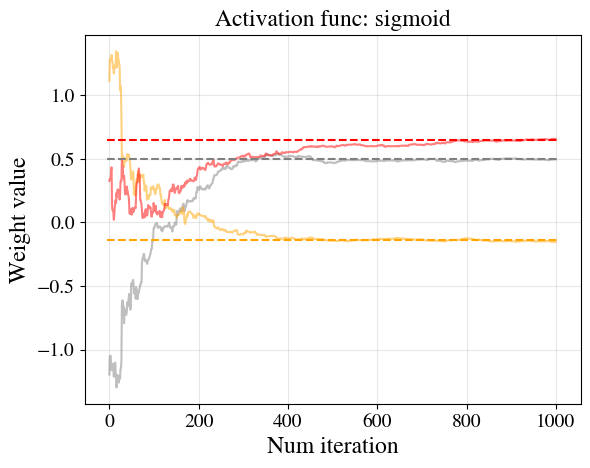

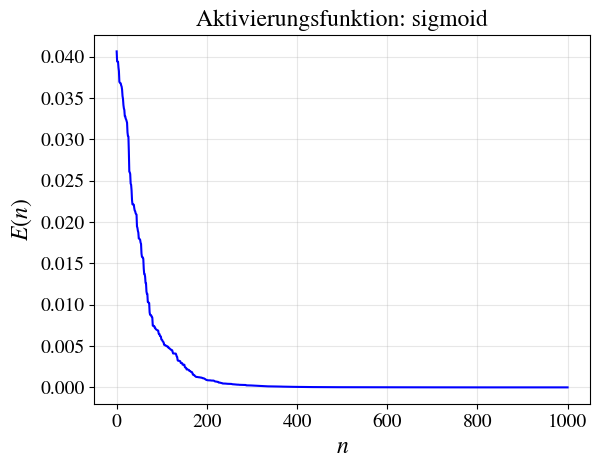

In [15]:
#---------------------------------------------------------------------#
#                          Execute network
#---------------------------------------------------------------------#
for activation in ['sigmoid']:  # Change this line for different activation function
        if activation=='sigmoid':
                sigma=0.01
                eta = 6
                num_iterations = 1000
        elif activation=='linear':
                sigma=0.01
                eta = 0.9
                num_iterations = 500
        # Create network instance
        readout = linear_perceptron(
                eta = eta,  # learning rate
                sigma = sigma,  # std of the gaussian noise
                T = 200,  # Vector length
                num_iterations = num_iterations,  # Number of iterations for weight update
                activation_type = activation,  # Set activation function
                use_teacher = True,  # Use teacher function
                plot_weight = True,  # Plot the weight evolution
                spike_number = 10,  # Total number of spikes
                input_neuron_number = 20,  # Number of neurons in input layer
        )

        # Train network
        output, expected_output, err, err_WP = readout.network_training()
